In [ ]:
# Data Handling and Preprocessing
import pandas as pd  # For loading and manipulating the dataset
import numpy as np   # For numerical operations, including handling arrays

# Data Scaling and Normalization
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder  # For scaling/normalizing the dataset to a range (0, 1)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Check for imbalance
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Import the seasonal_decompose function
from statsmodels.tsa.seasonal import seasonal_decompose

# Data Splitting
from sklearn.model_selection import train_test_split  # For splitting data into training, validation, and testing sets
from sklearn.model_selection import  GridSearchCV  # For hyperparameter tuning

# import the math module to access sqrt function.
import math
from sklearn.metrics import mean_squared_error

# Importing libraries for machine learning models and metrics
from sklearn.linear_model import Ridge  # For linear regression with L2 regularization
from sklearn.base import BaseEstimator, RegressorMixin  # For creating custom models

# TensorFlow & Keras for esn model
import tensorflow as tf  # For TensorFlow, which includes the Keras API for building neural networks
from tensorflow.keras.models import Sequential  # To create a linear stack of layers for the model
!pip install pyESN
# Restart the kernel after installation
#from pyESN import ESN # Import after kernel restart

# Model Evaluation and Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error ,make_scorer # To evaluate the model's performance using error metrics

# Visualization
import matplotlib.pyplot as plt  # For visualizing data and model results
import seaborn as sns  # For advanced visualization, especially for statistical plots

In [ ]:
import pandas as pd
data = pd.read_csv('CrimeDate (1).csv') # Load dataset

In [ ]:
# Inspect the data
print(data.head())  # Views the first 5 rows of the dataset
print(data.info())  # Checks the column names, data types, and non-null counts
print(data.describe())  # Get summary statistics for numerical columns

       date         primary_type  crime_count  arrest_count  false_count
0  1/1/2001  MOTOR VEHICLE THEFT           59             9           50
1  1/1/2001    WEAPONS VIOLATION           32            26            6
2  1/1/2001   DECEPTIVE PRACTICE           78            16           62
3  1/1/2001    CRIMINAL TRESPASS           29            17           12
4  1/1/2001             GAMBLING            2             2            0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141855 entries, 0 to 141854
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          141855 non-null  object
 1   primary_type  141855 non-null  object
 2   crime_count   141855 non-null  int64 
 3   arrest_count  141855 non-null  int64 
 4   false_count   141855 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.4+ MB
None
         crime_count   arrest_count    false_count
count  141855.000000  141855.000000  141855.0

In [ ]:
data['date'] = pd.to_datetime(data['date'], errors='coerce') #Datetime conversion ensures consistent handling of dates.

data.dropna(subset=['date'], inplace=True) #Check if any rows have invalid dates and drop them

print(data['date'].head()) #Confirm the conversion

0   2001-01-01
1   2001-01-01
2   2001-01-01
3   2001-01-01
4   2001-01-01
Name: date, dtype: datetime64[ns]


In [ ]:
data.set_index('date', inplace=True) # Set the date as the index

In [ ]:
# Get the unique values in the 'primary_type' column
unique_values = data['primary_type'].unique()

# Print the unique values
print(unique_values)
print(data['primary_type'].nunique())

['MOTOR VEHICLE THEFT' 'WEAPONS VIOLATION' 'DECEPTIVE PRACTICE'
 'CRIMINAL TRESPASS' 'GAMBLING' 'ROBBERY' 'BURGLARY'
 'INTERFERENCE WITH PUBLIC OFFICER' 'PUBLIC PEACE VIOLATION'
 'LIQUOR LAW VIOLATION' 'CRIMINAL SEXUAL ASSAULT' 'THEFT' 'NARCOTICS'
 'ASSAULT' 'OTHER OFFENSE' 'BATTERY' 'CRIMINAL DAMAGE'
 'OFFENSE INVOLVING CHILDREN' 'STALKING' 'SEX OFFENSE' 'PROSTITUTION'
 'HOMICIDE' 'ARSON' 'OBSCENITY' 'DOMESTIC VIOLENCE' 'KIDNAPPING'
 'OTHER NARCOTIC VIOLATION' 'INTIMIDATION' 'PUBLIC INDECENCY' 'RITUALISM'
 'NON-CRIMINAL' 'NON-CRIMINAL (SUBJECT SPECIFIED)' 'HUMAN TRAFFICKING'
 'CONCEALED CARRY LICENSE VIOLATION']
34


Outliers in 'crime_count':
               primary_type  crime_count  arrest_count  false_count
date                                                               
2001-01-01            THEFT          404            38          366
2001-01-01    OTHER OFFENSE          166            14          152
2001-01-01          BATTERY          294            79          215
2001-01-01  CRIMINAL DAMAGE          233            20          213
2001-01-02        NARCOTICS          175           175            0
...                     ...          ...           ...          ...
2022-05-16            THEFT          170             8          162
2022-05-17            THEFT          168             6          162
2022-05-19            THEFT          166            10          156
2022-05-30          BATTERY          182            36          146
2022-06-07            THEFT          171             5          166

[11102 rows x 4 columns]


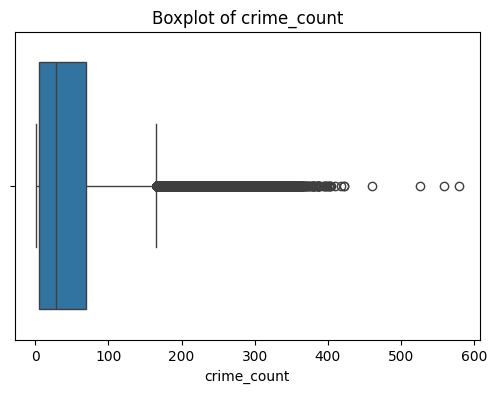

Outliers in 'arrest_count':
                 primary_type  crime_count  arrest_count  false_count
date                                                                 
2001-01-01              THEFT          404            38          366
2001-01-01          NARCOTICS           96            96            0
2001-01-01            BATTERY          294            79          215
2001-01-02            BATTERY          142            40          102
2001-01-02          NARCOTICS          175           175            0
...                       ...          ...           ...          ...
2022-01-01            BATTERY          138            33          105
2022-05-28  WEAPONS VIOLATION           43            34            9
2022-05-29  WEAPONS VIOLATION           58            38           20
2022-05-30            BATTERY          182            36          146
2022-05-30  WEAPONS VIOLATION           62            47           15

[14050 rows x 4 columns]


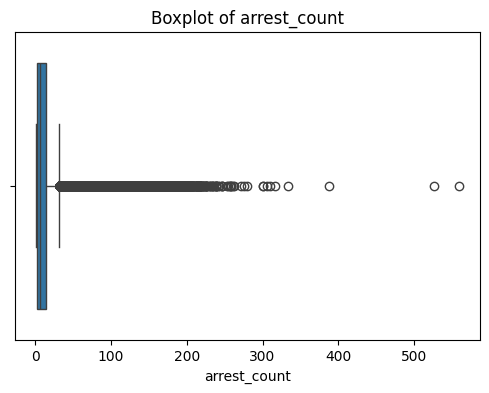

Outliers in 'false_count':
               primary_type  crime_count  arrest_count  false_count
date                                                               
2001-01-01            THEFT          404            38          366
2001-01-01    OTHER OFFENSE          166            14          152
2001-01-01          BATTERY          294            79          215
2001-01-01  CRIMINAL DAMAGE          233            20          213
2001-01-02            THEFT          221            33          188
...                     ...          ...           ...          ...
2022-06-10            THEFT          138             3          135
2022-06-11          BATTERY          141            11          130
2022-06-12          BATTERY          164            28          136
2022-06-13            THEFT          153             5          148
2022-06-14            THEFT          139            10          129

[12618 rows x 4 columns]


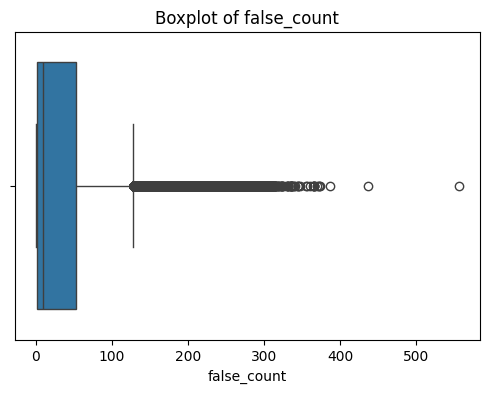

In [ ]:
# Import matplotlib.pyplot inside the function if it's not already imported
import matplotlib.pyplot as plt  # Import here to ensure availability
import seaborn as sns #Import seaborn and alias it as sns

# Function to detect outliers using the IQR method
def detect_outliers_iqr(data):
    # Loop through numerical columns
    for col in ['crime_count', 'arrest_count', 'false_count']:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

        # Print outliers for each feature
        print(f"Outliers in '{col}':")
        print(outliers)

        # Visualize outliers using a box plot
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=data[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

# Call the function to detect outliers
detect_outliers_iqr(data)

In [ ]:
# Function to handle outliers using IQR
def handle_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Apply outlier handling for each relevant feature
data = handle_outliers_iqr(data, 'crime_count')
data = handle_outliers_iqr(data, 'arrest_count')
data = handle_outliers_iqr(data, 'false_count')

In [ ]:
# Check the shape of the data after outlier removal
print(f"Data shape after outlier removal: {data.shape}")
print(data.head(10))

Data shape after outlier removal: (114417, 4)
                                primary_type  crime_count  arrest_count  \
date                                                                      
2001-01-01               MOTOR VEHICLE THEFT           59             9   
2001-01-01                DECEPTIVE PRACTICE           78            16   
2001-01-01                 CRIMINAL TRESPASS           29            17   
2001-01-01                          GAMBLING            2             2   
2001-01-01                           ROBBERY           40             5   
2001-01-01                          BURGLARY           65             5   
2001-01-01  INTERFERENCE WITH PUBLIC OFFICER            1             1   
2001-01-01            PUBLIC PEACE VIOLATION            5             2   
2001-01-01              LIQUOR LAW VIOLATION            3             3   
2001-01-01           CRIMINAL SEXUAL ASSAULT           35            12   

            false_count  
date                     
2

In [ ]:
# Aggregate the data by date and primary_type
agg_data = data.groupby(['date', 'primary_type']).sum().reset_index()

# Display the aggregated data
print(agg_data.head(10))

        date                      primary_type  crime_count  arrest_count  \
0 2001-01-01                           ASSAULT           70            20   
1 2001-01-01                          BURGLARY           65             5   
2 2001-01-01           CRIMINAL SEXUAL ASSAULT           35            12   
3 2001-01-01                 CRIMINAL TRESPASS           29            17   
4 2001-01-01                DECEPTIVE PRACTICE           78            16   
5 2001-01-01                          GAMBLING            2             2   
6 2001-01-01  INTERFERENCE WITH PUBLIC OFFICER            1             1   
7 2001-01-01              LIQUOR LAW VIOLATION            3             3   
8 2001-01-01               MOTOR VEHICLE THEFT           59             9   
9 2001-01-01        OFFENSE INVOLVING CHILDREN           87            13   

   false_count  
0           50  
1           60  
2           23  
3           12  
4           62  
5            0  
6            0  
7            0  

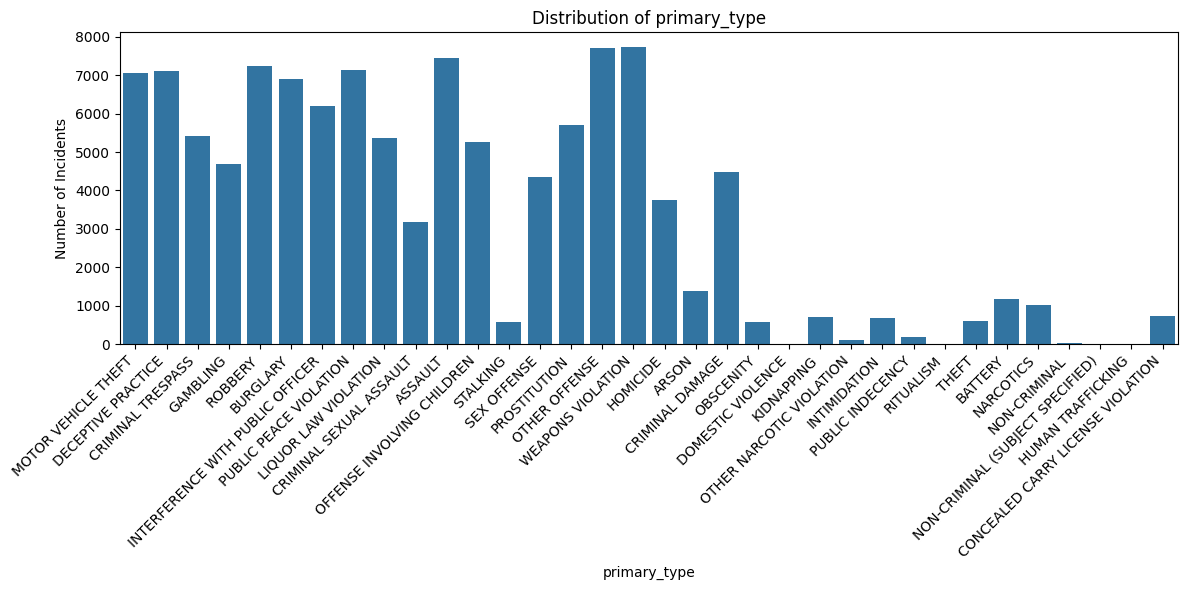

In [ ]:
categorical_features = ['primary_type']

for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=data, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45, ha='right')  # Rotate labels and align them to the right
    plt.ylabel('Number of Incidents')
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
    plt.show()

In [ ]:
print(data['primary_type'].value_counts())

primary_type
WEAPONS VIOLATION                    7730
OTHER OFFENSE                        7700
ASSAULT                              7451
ROBBERY                              7252
PUBLIC PEACE VIOLATION               7131
DECEPTIVE PRACTICE                   7119
MOTOR VEHICLE THEFT                  7061
BURGLARY                             6906
INTERFERENCE WITH PUBLIC OFFICER     6199
PROSTITUTION                         5701
CRIMINAL TRESPASS                    5417
LIQUOR LAW VIOLATION                 5361
OFFENSE INVOLVING CHILDREN           5259
GAMBLING                             4693
CRIMINAL DAMAGE                      4475
SEX OFFENSE                          4348
HOMICIDE                             3759
CRIMINAL SEXUAL ASSAULT              3177
ARSON                                1368
BATTERY                              1160
NARCOTICS                            1013
CONCEALED CARRY LICENSE VIOLATION     718
KIDNAPPING                            706
INTIMIDATION         

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Identify the most frequent category count
max_count = data['primary_type'].value_counts().max()

# Function to oversample each category in 'primary_type'
def oversample_primary_type(data):
    oversampled_data = []
    for category in data['primary_type'].unique():
        category_data = data[data['primary_type'] == category]
        oversampled = resample(category_data, replace=True, n_samples=max_count, random_state=42)
        oversampled_data.append(oversampled)
    return pd.concat(oversampled_data)

# Apply oversampling
balanced_data = oversample_primary_type(data)

print("Original dataset shape:", data.shape)
print("Balanced dataset shape:", balanced_data.shape)
print(balanced_data['primary_type'].value_counts())

Original dataset shape: (114417, 4)
Balanced dataset shape: (262820, 4)
primary_type
MOTOR VEHICLE THEFT                  7730
PUBLIC INDECENCY                     7730
CRIMINAL DAMAGE                      7730
OBSCENITY                            7730
DOMESTIC VIOLENCE                    7730
KIDNAPPING                           7730
OTHER NARCOTIC VIOLATION             7730
INTIMIDATION                         7730
RITUALISM                            7730
DECEPTIVE PRACTICE                   7730
THEFT                                7730
BATTERY                              7730
NARCOTICS                            7730
NON-CRIMINAL                         7730
NON-CRIMINAL (SUBJECT SPECIFIED)     7730
HUMAN TRAFFICKING                    7730
ARSON                                7730
HOMICIDE                             7730
WEAPONS VIOLATION                    7730
OTHER OFFENSE                        7730
PROSTITUTION                         7730
SEX OFFENSE                      

In [ ]:
print(data.describe())

         crime_count   arrest_count    false_count
count  114417.000000  114417.000000  114417.000000
mean       27.650603       5.849804      21.800799
std        28.320255       5.381128      26.347894
min         1.000000       1.000000       0.000000
25%         4.000000       2.000000       0.000000
50%        15.000000       4.000000       6.000000
75%        46.000000       8.000000      40.000000
max       130.000000      24.000000     106.000000


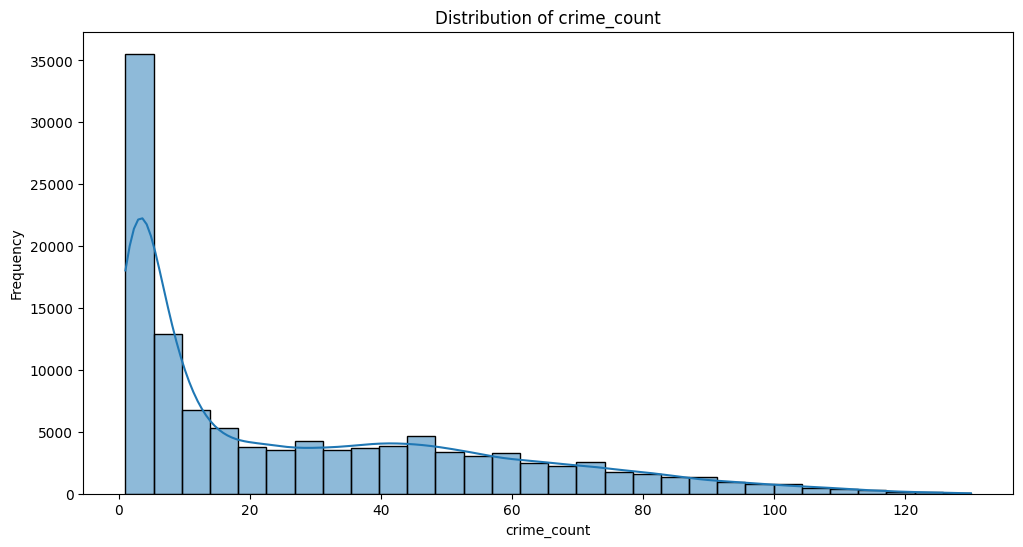

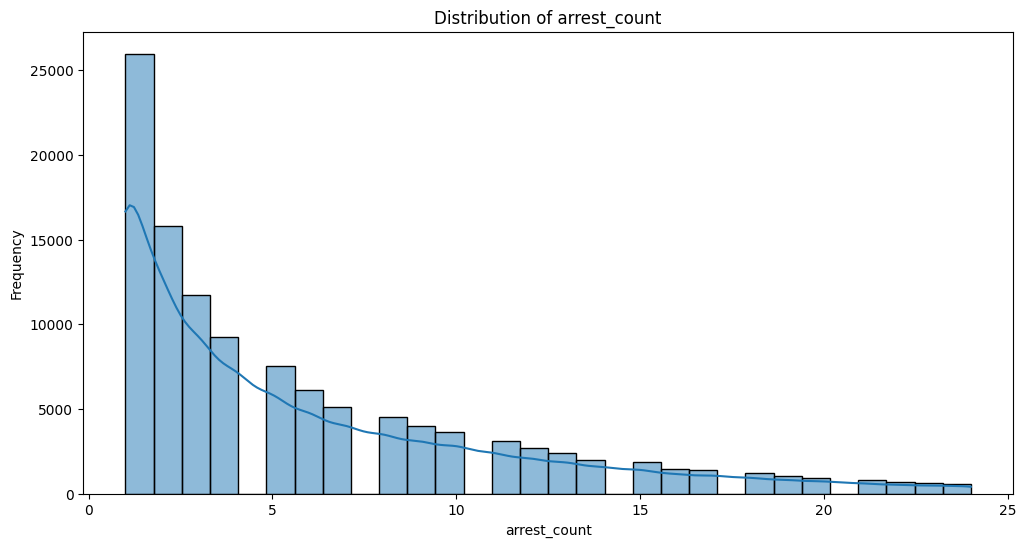

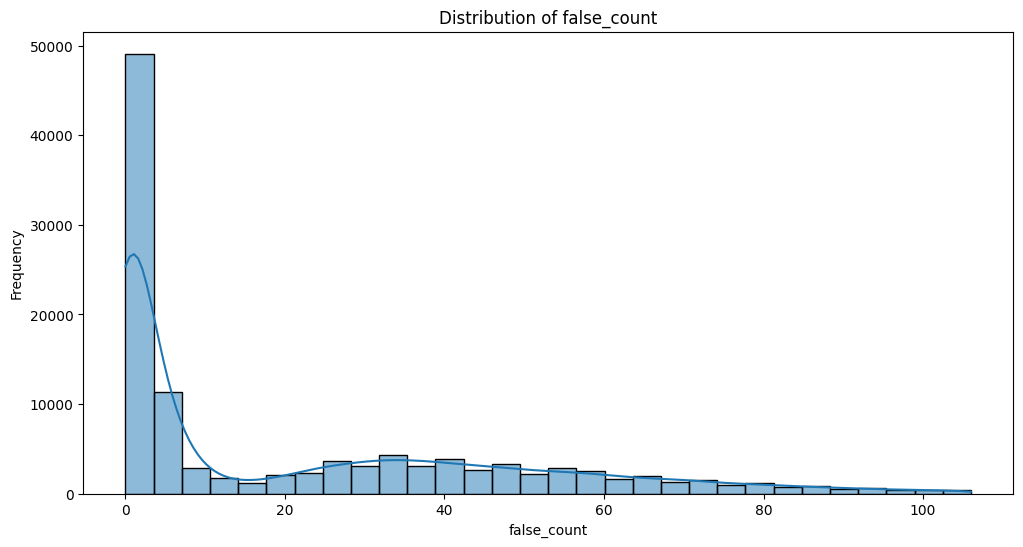

In [ ]:
# Check for imbalance in numerical features (excluding 'arrest')
numerical_features = ['crime_count', 'arrest_count', 'false_count']  # Exclude 'arrest'

for feature in numerical_features:
    plt.figure(figsize=(12, 6))
    sns.histplot(agg_data[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
# Specify the numerical features to handle
numerical_features = ['crime_count', 'arrest_count', 'false_count']  # Replace with your actual numerical feature names

# Step 1: Log Transformation (to reduce skewness)
for feature in numerical_features:
    agg_data[feature] = agg_data[feature].apply(lambda x: np.log1p(x))  # log1p handles zero values

# Check the transformed data
print(agg_data[numerical_features].describe())

         crime_count   arrest_count    false_count
count  114417.000000  114417.000000  114417.000000
mean        2.722189       1.643301       2.088450
std         1.233496       0.744731       1.636798
min         0.693147       0.693147       0.000000
25%         1.609438       1.098612       0.000000
50%         2.772589       1.609438       1.945910
75%         3.850148       2.197225       3.713572
max         4.875197       3.218876       4.672829


In [ ]:
# One-hot encode the 'primary_type' column
agg_data_ohe = pd.get_dummies(agg_data, columns=['primary_type'], drop_first=True)

# Display the first few rows of the transformed data
print(agg_data_ohe.head())

        date  crime_count  arrest_count  false_count  primary_type_ASSAULT  \
0 2001-01-01     4.262680      3.044522     3.931826                  True   
1 2001-01-01     4.189655      1.791759     4.110874                 False   
2 2001-01-01     3.583519      2.564949     3.178054                 False   
3 2001-01-01     3.401197      2.890372     2.564949                 False   
4 2001-01-01     4.369448      2.833213     4.143135                 False   

   primary_type_BATTERY  primary_type_BURGLARY  \
0                 False                  False   
1                 False                   True   
2                 False                  False   
3                 False                  False   
4                 False                  False   

   primary_type_CONCEALED CARRY LICENSE VIOLATION  \
0                                           False   
1                                           False   
2                                           False   
3                 

In [ ]:
#Normalization
numerical_features = ['crime_count', 'arrest_count', 'false_count']  # Replace with your actual numerical feature names
scaler = MinMaxScaler()
agg_data[numerical_features] = scaler.fit_transform(agg_data[numerical_features])

In [ ]:
# Check the transformed data
print(agg_data.describe())

                                date    crime_count   arrest_count  \
count                         114417  114417.000000  114417.000000   
mean   2011-07-04 21:00:29.544560384       0.485179       0.376190   
min              2001-01-01 00:00:00       0.000000       0.000000   
25%              2006-04-07 00:00:00       0.219101       0.160534   
50%              2011-07-07 00:00:00       0.497230       0.362783   
75%              2016-09-06 00:00:00       0.754893       0.595502   
max              2022-06-14 00:00:00       1.000000       1.000000   
std                              NaN       0.294950       0.294858   

         false_count  
count  114417.000000  
mean        0.446935  
min         0.000000  
25%         0.000000  
50%         0.416431  
75%         0.794716  
max         1.000000  
std         0.350280  


In [ ]:
# Inspect the data
print(agg_data.head())  # Views the first 5 rows of the dataset
print(agg_data.info())  # Checks the column names, data types, and non-null counts
print(agg_data.describe())  # Get summary statistics for numerical columns

        date             primary_type  crime_count  arrest_count  false_count
0 2001-01-01                  ASSAULT     0.853537      0.930969     0.841423
1 2001-01-01                 BURGLARY     0.836075      0.434968     0.879740
2 2001-01-01  CRIMINAL SEXUAL ASSAULT     0.691138      0.741094     0.680113
3 2001-01-01        CRIMINAL TRESPASS     0.647541      0.869937     0.548907
4 2001-01-01       DECEPTIVE PRACTICE     0.879067      0.847306     0.886644
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114417 entries, 0 to 114416
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          114417 non-null  datetime64[ns]
 1   primary_type  114417 non-null  object        
 2   crime_count   114417 non-null  float64       
 3   arrest_count  114417 non-null  float64       
 4   false_count   114417 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 4.

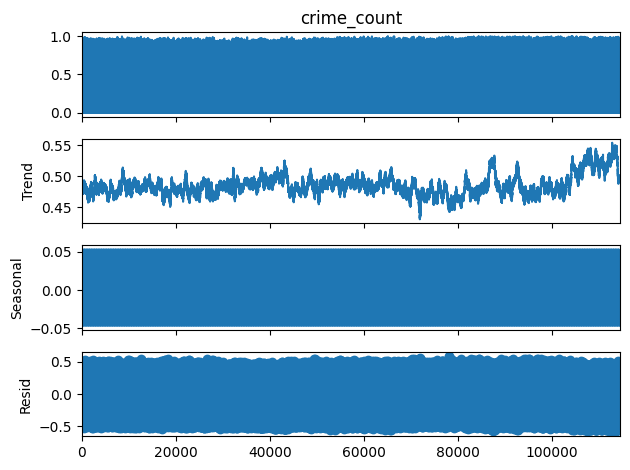

In [ ]:
# Assuming 'crime_count' is the time series to decompose
decomp_annual = seasonal_decompose(agg_data['crime_count'], model='additive', period=365)

# Plot the decomposition
decomp_annual.plot()
plt.show()

In [ ]:
duplicates = agg_data.duplicated(subset=['date', 'primary_type']).sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


In [ ]:
# Define the target variable and features
target_variable = 'crime_count'  # Ensure this matches the column name in agg_data
if target_variable in agg_data.columns:
    X = agg_data.drop([target_variable, 'date'], axis=1)  # Features # Drop 'date' here
    y = agg_data[target_variable]  # Target variable
else:
    print(f"Column '{target_variable}' not found in aggregated data.")

X = agg_data.drop([target_variable, 'date'], axis=1)  # Features

In [ ]:
# Define the split indices
train_size = int(len(agg_data) * 0.7)
val_size = int(len(agg_data) * 0.15)

# Split the data into X (features) and y (target)
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

# Reshape inputs for LSTM (after data type conversion)
train_X = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))  # Reshape to (samples, timesteps, features)
val_X = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))
test_X = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Check the sizes of the splits
print(f"Training set size: {X_train.shape[0]} samples, {y_train.shape[0]} target values")
print(f"Validation set size: {X_val.shape[0]} samples, {y_val.shape[0]} target values")
print(f"Test set size: {X_test.shape[0]} samples, {y_test.shape[0]} target values")

Training set size: 80091 samples, 80091 target values
Validation set size: 17162 samples, 17162 target values
Test set size: 17164 samples, 17164 target values


In [ ]:
# Select relevant columns and reshape data for scaling
data = agg_data[['crime_count', 'arrest_count', 'false_count']].values  # We don't reshape here, keep it 2D

# Normalize the data to a range between 0 and 1 for better training
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

The code is used to select specific columns from a DataFrame, reshape the data for scaling, and then normalize the data using Min-Max scaling to help improve the convergence speed of gradient-based optimization and ensure that no single feature dominates the learning process due to its scale.

- data = agg_data[['crime_count', 'arrest_count', 'false_count']].values
  - Selects crime_count, arrest_count, and false_count from the DataFrame agg_data.
  - .values
    - Converts selected columns into a NumPy array; it will be 2D, where each row corresponds to a sample and each column corresponds to one of the selected features.

- scaler = MinMaxScaler()
  - Scales features to a specified range,between 0 and 1; ensuring that all features contribute equally to the model training.

- data_scaled = scaler.fit_transform(data)
  - fits the scaler to the data and then transforms it; calculates the minimum and maximum values for each feature and scales the data accordingly.
  - data_scaled,
    - NumPy array where each feature is scaled to the range [0, 1].
    


In [ ]:
# Prepare Data for esn (2D X, 2D y)

# Function to prepare data as 2D (X, y)
def prepare_data(data, n_steps):
    """
    Convert time-series data into 2D dataset where:
    - X will have n_steps rows and 1 column for each feature
    - y will be the next value at the subsequent time step
    """
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps].flatten())  # Flatten the timestep data to make it 2D
        y.append(data[i + n_steps])              # The target for the next timestep
    return np.array(X), np.array(y)

n_steps = 10  # Number of timesteps you want to look back for prediction
X, y = prepare_data(data_scaled, n_steps)

# X will be 2D with shape (samples, timesteps * features)
# y will be 2D with shape (samples, 1)
print("Shape of X:", X.shape)  # Should be (samples, timesteps * features)
print("Shape of y:", y.shape)  # Should be (samples, 1)

Shape of X: (114407, 30)
Shape of y: (114407, 3)


This code effectively prepares time-series data for training a model by converting it into a 2D format suitable for prediction tasks, it is essential for training models like Echo State Networks.

- def prepare_data(data, n_steps):
  - defines a function that takes two arguments; data (scaled time-series data) and n_steps ( number of time steps to look back for making predictions).

  - X, y = [], []
    - Two empty lists, X and y, initialized to store input features and target values

  - for i in range(len(data) - n_steps):
    - iterates through the data array, stopping n_steps samples before the end; ensuring there are enough data points to create input-output pairs.
    - X.append(data[i:i + n_steps].flatten())  
      - takes a slice of the data from index i to i + n_steps, flattens it into a 1D array, and appends it to the list X; each row in X will contain the values of all features for the last n_steps time steps.
    - y.append(data[i + n_steps])   
      - appends the value at the next time step ( value immediately following the n_steps time steps) to the list y. This is the target value that the model will learn to predict.    
  - return np.array(X), np.array(y)
    - lists X and y are converted to NumPy arrays and returned.  

- n_steps = 10  
  - sets the number of time steps to look back for making predictions.

- X, y = prepare_data(data_scaled, n_steps)
  - calls prepare_data with the scaled data and specified number of time steps, storing the resulting arrays in X and y.

- print("Shape of X:", X.shape)  
  - X.shape
    - structure looks like (samples, n_steps * features), samples is the number of input sequences created, n_steps is number of time steps, and features is number of features in the original data.

- print("Shape of y:", y.shape)  # Should be (samples, 1)
  - y.shape
    - structured as (samples, 1), indicating that there is one target value for each input sequence.

- Output Analysis:
  - Shape of X: (114407, 30)
    - Number of Samples: 114407; each sample corresponds to a sequence of past observations used for making predictions.
    - Number of Features: 30; each input sequence consists of 30 features, this could mean that for each sample, we are using 30 time steps of data, and each time step has multiple features.

  - Shape of y: (114407, 3)
    - Number of Samples: 114407; matches the number of samples in X, means that for each input sequence in X, there is a corresponding target output in y.
    - Number of Target Variables: 3; we are predicting 3 target variables for each input sequence, means that we are trying to predict multiple outcomes simultaneously.

In [ ]:
# Split Data into Train, Validation, and Test Sets (15%, 15%, 70%)

train_len = int(len(X) * 0.7)  # 70% for training
val_len = int(len(X) * 0.15)   # 15% for validation

# Splitting data
X_train, X_val, X_test = X[:train_len], X[train_len:train_len + val_len], X[train_len + val_len:]
y_train, y_val, y_test = y[:train_len], y[train_len:train_len + val_len], y[train_len + val_len:]

# Check the shapes
print("Shape of X_train:", X_train.shape)  # (samples, timesteps * features)
print("Shape of y_train:", y_train.shape)  # (samples, 1)

print("Shape of X_val:", X_val.shape)  # (samples, timesteps * features)
print("Shape of y_val:", y_val.shape)  # (samples, 1)

print("Shape of X_test:", X_test.shape)  # (samples, timesteps * features)
print("Shape of y_test:", y_test.shape)  # (samples, 1)

Shape of X_train: (80084, 30)
Shape of y_train: (80084, 3)
Shape of X_val: (17161, 30)
Shape of y_val: (17161, 3)
Shape of X_test: (17162, 30)
Shape of y_test: (17162, 3)


The code is used to split the prepared datasets (X and y) into training, validation, and test sets based on specified proportions (70% for training, 15% for validation, and 15% for testing).

- train_len = int(len(X) * 0.7)  
  - calculates number of samples to be used for the training set; 70% of the total number of samples in X.
- val_len = int(len(X) * 0.15)   
  - calculates number of samples used for validation set; 15% of the total number of samples in X.

- X_train, X_val, X_test = X[:train_len], X[train_len:train_len + val_len], X
[train_len + val_len:]
- y_train, y_val, y_test = y[:train_len], y[train_len:train_len + val_len], y[train_len + val_len:]
  - X_train and y_train: The first 70% of the data.
  - X_val and y_val: The next 15% of the data.
  - X_test and y_test: The remaining 15% of the data.
  - slicing ensures that the samples are divided sequentially, maintaining the order of the time-series data.

-print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)  

print("Shape of X_val:", X_val.shape)  
print("Shape of y_val:", y_val.shape)  

print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)
  - prints the shapes of the training, validation, and test sets for X and y.


- Output Analysis:
  - X_train: (80084, 30)
    - Indicates there are 80,084 samples in the training set, with each sample having 30 features.
  - y_train: (80084, 3)
    - Target variable has 3 outputs for each sample, suggesting that we are predicting three different target variables simultaneously.
  
  - X_val: (17161, 30)
    - Contains 17,161 samples, which is a good size for tuning hyperparameters and validating the model's performance during training.
  - y_val: (17161, 3)
   - Target variable for validation set also has 3 outputs, consistent with the training set.

  - X_test: (17162, 30)
    - Contains 17,162 samples, which is slightly larger than the validation set; provides a robust evaluation of the model's performance on unseen data.
  - y_test: (17162, 3)
    - Target variable for test set has 3 outputs, maintaining consistency with the other sets.


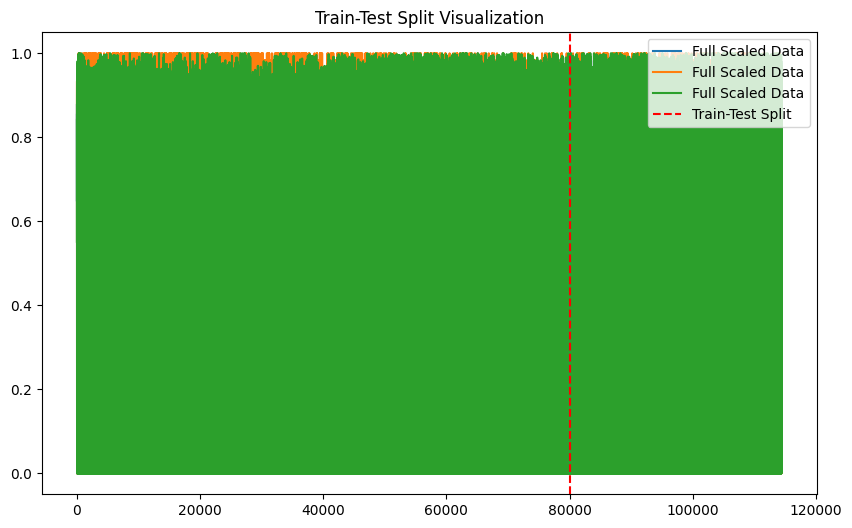

In [ ]:
# Visualize Train-Test Split
plt.figure(figsize=(10, 6))
plt.plot(data_scaled, label="Full Scaled Data")
plt.axvline(x=train_len, color='red', linestyle='--', label="Train-Test Split")
plt.title("Train-Test Split Visualization")
plt.legend()
plt.show()

The code is used to visualize the train-test split of the scaled data. This helps to understand how the data is divided into training and testing sets which is crucial for ensuring that the model is trained and evaluated correctly.
and confirming that the split respects the temporal nature of the data, as well as identifying if there are any issues with the data distribution or if the split point is appropriate.

- plt.figure(figsize=(10, 6))
  - initializes a new figure for the plot with a specified size of 10 inches wide and 6 inches tall.

- plt.plot(data_scaled, label="Full Scaled Data")
  - plots the entire scaled dataset (data_scaled). The label parameter is used to create a legend entry for this line.

- plt.axvline(x=train_len, color='red', linestyle='--', label="Train-Test Split")
  - adds a vertical dashed line at the position train_len,representing the point where the training data ends and the test data begins;line is red and  dashed. Label parameter is used to create a legend entry for this line.

- plt.title("Train-Test Split Visualization")
  - sets the title of the plot.

- plt.legend()
  - isplays the legend; including labels for plotted data and vertical line.

- plt.show()
  - displays the plot.

- Output Analysis:
  - The green section represents the data used for training, while the area beyond the red vertical line represents the testing data.
  - The train-test split respects the sequential nature of the data, ensuring that no future information from the test set leaks into the training phase.
  - The consistent scaling of the data across both sets suggests that proper preprocessing was applied.

In [ ]:
# Define the Echo State Network (ESN) class (Improved Initialization)
class EchoStateNetwork:
    def __init__(self, n_input, n_reservoir, n_output, spectral_radius=0.95, input_scaling=1.0, regularization=1e-8, sparsity=0.1, random_state=None):
        self.n_input = n_input
        self.n_reservoir = n_reservoir
        self.n_output = n_output
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.regularization = regularization
        self.sparsity = sparsity
        self.random_state = random_state

        # Initialize random state for reproducibility
        if random_state is not None:
          np.random.seed(random_state)

        # Initialize weights with better random initialization
        self.input_weights = (np.random.rand(n_reservoir, n_input + 1) - 0.5) * self.input_scaling
        self.reservoir_weights = np.random.rand(n_reservoir, n_reservoir) - 0.5
        self._scale_reservoir_weights(sparsity)  # Call the method to scale weights


    def _scale_reservoir_weights(self, sparsity):
        """Scales reservoir weights and applies sparsity."""
        # Normalize to spectral radius
        radius = np.max(np.abs(np.linalg.eigvals(self.reservoir_weights)))
        self.reservoir_weights = self.reservoir_weights * (self.spectral_radius / radius)

        # Apply sparsity (setting weights to 0)
        mask = np.random.rand(*self.reservoir_weights.shape) < sparsity
        self.reservoir_weights[mask] = 0

    def _reservoir_state_update(self, state, input_data):
        """Updates the reservoir state."""
        pre_activation = np.dot(self.reservoir_weights, state) + np.dot(self.input_weights, np.hstack([1, input_data]))  # Add bias term
        return np.tanh(pre_activation)  # Apply activation function

    def fit(self, inputs, outputs):
        """Trains the ESN model."""
        n_samples = inputs.shape[0]
        state = np.zeros(self.n_reservoir)  # Initial state
        states = np.zeros((n_samples, self.n_reservoir))  # To store reservoir states

        # Collect reservoir states
        for t in range(n_samples):
            state = self._reservoir_state_update(state, inputs[t])
            states[t] = state

        # Train readout weights using Ridge regression
        self.readout = Ridge(alpha=self.regularization, fit_intercept=False)
        self.readout.fit(states, outputs)

    def predict(self, inputs):
        """Makes predictions using the trained ESN model."""
        n_samples = inputs.shape[0]
        state = np.zeros(self.n_reservoir)  # Initial state
        outputs = np.zeros((n_samples, self.n_output))

        for t in range(n_samples):
            state = self._reservoir_state_update(state, inputs[t])
            outputs[t] = self.readout.predict(state.reshape(1, -1))

        return outputs

The code defines an Echo State Network (ESN) class, that is particularly well-suited for time series prediction and other sequential data tasks.The architecture leverages the unique properties of reservoir computing, allowing it to effectively model complex temporal dynamics while maintaining computational efficiency.

- class EchoStateNetwork:
    def __init__(self, n_input, n_reservoir, n_output, spectral_radius=0.95, input_scaling=1.0, regularization=1e-8, sparsity=0.1, random_state=None):
    - constructor method for EchoStateNetwork class; initializes parameters and sets up network's structure.
    - Parameters:
      - n_input: Number of input features.
      - n_reservoir: Number of neurons in the reservoir; larger reservoir can capture more complex dynamics
      - n_output: Number of output features; how many outputs the network will produce.
      - spectral_radius: Controls the stability of the reservoir dynamics; less than or equal to 1 for stability.
      - input_scaling: Scaling factor for the input weights.
      - regularization: for the Ridge regression used in training the output weights to prevent overfitting.
      - sparsity: Fraction of weights in the reservoir that are set to zero (to create a sparse network).
      - random_state: Seed for random number generation to ensure reproducibility.

    -  if random_state is not None:
        np.random.seed(random_state)
        -  checks if a random_state is provided, it sets the seed for NumPy's random number generator; ensuring the random initialization is reproducible across different runs.

      - self.input_weights = (np.random.rand(n_reservoir, n_input + 1) - 0.5) * self.input_scaling
        - initializes input_weights randomly between -0.5 and 0.5 and then scaled by input_scaling; shape of input_weights is (n_reservoir, n_input + 1) to include a bias term (the additional 1 in the input dimension).
      - self.reservoir_weights = np.random.rand(n_reservoir, n_reservoir) - 0.5
        - initializes resorvoir_weights randomly between -0.5 and 0.5; shape is (n_reservoir, n_reservoir) since each neuron in the reservoir is connected to every other neuron.
      - self._scale_reservoir_weights(sparsity)  
        - called to adjust the reservoir weights according to the specified spectral radius and sparsity.
      
      - def _scale_reservoir_weights(self, sparsity):
        - radius = np.max(np.abs(np.linalg.eigvals(self.reservoir_weights)))
        self.reservoir_weights = self.reservoir_weights * (self.spectral_radius / radius)
          - spectral radius of the reservoir weights is calculated using the eigenvalues,  weights are then scaled so that the maximum eigenvalue matches the specified spectral_radius; ensuring that the dynamics of the reservoir are stable.
        - mask = np.random.rand(*self.reservoir_weights.shape) < sparsity
        self.reservoir_weights[mask] = 0
          - creates a mask using random values to determine which weights will be set to zero, introducing sparsity into the reservoir, improving generalization and reducing computational complexity.

      - def _reservoir_state_update(self, state, input_data):
         - computes the new state of the reservoir based on the current state and the input data.
        - pre_activation = np.dot(self.reservoir_weights, state) + np.dot(self.input_weights, np.hstack([1, input_data]))
          - np.dot used to calculate the weighted sum of the reservoir's current state and the input data, input data is augmented with a bias term (1) to account for the bias in the input weights.  
        - return np.tanh(pre_activation)  
          - np.tanh applied to the pre-activation values to introduce non-linearity to help learn complex patterns in the data.
      
      - def train(self, input_data, target_data):
        - states = np.zeros((len(input_data), self.n_reservoir))
          - states; an array that stores the reservoir states for each time step and is updated iteratively for each input data point.
       - for t in range(len(input_data)):
            states[t] = self._reservoir_state_update(states[t-1], input_data[t]) if t > 0 else np.zeros(self.n_reservoir)
              - adds bias term to the reservoir states before training the output weights, allowing the output layer to learn a constant offset.
        - states = np.hstack([np.ones((states.shape[0], 1)), states])  
        self.output_weights = np.linalg.solve(states.T @ states + self.regularization * np.eye(states.shape[1]), states.T @ target_data)
          - output weights are trained using Ridge regression, that includes a regularization term to prevent overfitting, solution is then computed using the normal equation, which involves matrix operations.

      -  def predict(self, input_data):
        - inputs is Input data for prediction (shape: (n_samples, n_input)).
        - n_samples = inputs.shape[0]
        state = np.zeros(self.n_reservoir)  # Initial state
        outputs = np.zeros((n_samples, self.n_output))
          - Initializes a zero reservoir state (state), and then creates an array (outputs) to store predictions.
        - for t in range(len(input_data)):
            states[t] = self._reservoir_state_update(states[t-1], input_data[t]) if t > 0 else np.zeros(self.n_reservoir)
              - Iteratively Updates the reservoir state , and uses the trained self.readout model to generate predictions.

        - states = np.hstack([np.ones((states.shape[0], 1)), states])  
          - states.shape[0]
            - number of rows in the states matrix.
          - np.ones((states.shape[0], 1))
            - creates a column vector of ones with the same number of rows as states.
          - np.hstack([...])
            - Horizontally concatenates the bias column to the states matrix.

        - return states @ self.output_weights
          - @
            - Matrix multiplication
          - self.output_weights
            - weight matrix learned during training that maps the reservoir states to the final output.
          - states @ self.output_weights
            - computes the dot product of the augmented states (including bias) and the output weights.  


In [ ]:
class ESNWithNoise:
    def __init__(self, n_reservoir=200, spectral_radius=0.95, input_scaling=0.1,
                 regularization=1e-8, sparsity=0.1, noise_std=0.0, dropout_rate=0.0):
        """
        ESN with support for dropout and noise injection.
        Args:
            n_reservoir: Number of reservoir neurons.
            spectral_radius: Scaling factor for the reservoir matrix to ensure stability.
            input_scaling: Scaling factor for input weights.
            regularization: Ridge regression regularization term.
            sparsity: Fraction of reservoir weights set to zero.
            noise_std: Standard deviation of Gaussian noise injected into reservoir states.
            dropout_rate: Fraction of reservoir neurons to drop during training.
        """
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.regularization = regularization
        self.sparsity = sparsity
        self.noise_std = noise_std
        self.dropout_rate = dropout_rate

        # Initialize W_in, W_res, and W_out as None; populated during training.
        self.W_in = None
        self.W_res = None
        self.W_out = None

    def _initialize_weights(self):
        # Initialize input weights (W_in) and reservoir weights (W_res)
        self.W_in = np.random.uniform(-1, 1, (self.n_reservoir, 1)) * self.input_scaling
        self.W_res = np.random.rand(self.n_reservoir, self.n_reservoir) - 0.5
        self.W_res *= 2 * np.random.rand(self.n_reservoir, self.n_reservoir) - 1  # Random initialization
        self.W_res = self.W_res / np.max(np.abs(np.linalg.eigvals(self.W_res)))  # Normalize spectral radius

    def _apply_dropout(self, state):
        """Apply dropout to the reservoir state."""
        if self.dropout_rate > 0:
            dropout_mask = np.random.rand(*state.shape) > self.dropout_rate
            return state * dropout_mask
        return state

    def _apply_noise(self, state):
        """Apply Gaussian noise to the reservoir state."""
        if self.noise_std > 0:
            noise = np.random.normal(0, self.noise_std, state.shape)
            return state + noise
        return state

    def fit(self, X, y):
        self._initialize_weights()

        # Initial reservoir state
        reservoir_state = np.zeros(self.n_reservoir)
        states = []

        # Generate reservoir states
        for t in range(len(X)):
            reservoir_state = np.tanh(
                np.dot(self.W_in, X[t]) + np.dot(self.W_res, reservoir_state)
            )
            # Apply noise and dropout during training
            reservoir_state = self._apply_dropout(reservoir_state)
            reservoir_state = self._apply_noise(reservoir_state)
            states.append(reservoir_state)

        states = np.array(states)

        # Train output weights (W_out) using Ridge regression
        self.W_out = Ridge(alpha=self.regularization).fit(states, y).coef_

    def predict(self, X):
        reservoir_state = np.zeros(self.n_reservoir)
        predictions = []

        # Use trained W_out to predict outputs
        for t in range(len(X)):
            reservoir_state = np.tanh(
                np.dot(self.W_in, X[t]) + np.dot(self.W_res, reservoir_state)
            )
            predictions.append(np.dot(self.W_out, reservoir_state))

        return np.array(predictions)

This class implements an Echo State Network (ESN) with added support for noise injection and dropout, which enhances robustness and generalization and to void overfitting from occuring to the model.

- def __init__(self, n_reservoir=200, spectral_radius=0.95, input_scaling=0.1,
            regularization=1e-8, sparsity=0.1, noise_std=0.0, dropout_rate=0.0):

  - def _initialize_weights(self):


In [ ]:
# Generate synthetic data
X_train = np.random.rand(100, 1)  # 100 time steps, 1 feature
y_train = np.sin(X_train)  # Sine wave as target

X_test = np.random.rand(20, 1)  # Test data
y_test = np.sin(X_test)  # Test target

This code snippet generates synthetic data for training and testing, where the target values (y_train and y_test) are based on a sine wave function, to test and validate ESN in a controlled environment. We chose sine wave because it’s simple, predictable, and representative of periodic patterns often found in real-world time-series tasks.

- X_train = np.random.rand(100, 1)
  - np.random.rand(100, 1)
    - generates (100, 1) matrix of random numbers in the range [0,1):
      - 100 rows: Represents 100 time steps (or data points).
      - 1 column: Represents a single feature for each time step.
- y_train = np.sin(X_train)
  - np.sin(X_train)
    - computes the sine of each value in X_train ,making it suitable for testing models designed for time series or sequence data.  

- X_test = np.random.rand(20, 1)  
  - np.random.rand(20, 1)
    - generates a (20, 1) matrix of random numbers in the range [0,1):
      - 20 rows: Represents 20 time steps (or data points) for testing.
      - 1 column: Single feature for each time step.
- y_test = np.sin(X_test)  
  - np.sin(X_test)
    - computes the sine of each value in X_test, mirroring the process used for training data.



In [ ]:
# Initialize the ESN model
esn_model = ESNWithNoise(
    n_reservoir=100,         # Number of neurons in the reservoir
    spectral_radius=0.9,     # Stability of the reservoir dynamics
    input_scaling=0.5,       # Scaling factor for input weights
    regularization=1e-7,     # Regularization parameter for Ridge regression
    sparsity=0.2,            # Sparsity of the reservoir connections
    noise_std=0.01,          # Standard deviation of noise
    dropout_rate=0.1         # Fraction of reservoir neurons to drop
)

This code initializes an instance of the ESNWithNoise class with specific parameters for the Echo State Network (ESN) to shape the ESN's ability to learn and generalize patterns in time-series data.

- esn_model = ESNWithNoise
  -  n_reservoir=100,
    - Specifies number of neurons in the reservoir & controls the capacity of the reservoir to store and process information.        
  - spectral_radius=0.9,
    - Scales the reservoir's weight matrix to ensure stability in its dynamics; values < 1 typically ensure the reservoir remains stable (avoids exploding states).     
  - input_scaling=0.5,
    - Scales the input weights to control how strongly the input affects the reservoir states;larger values make the reservoir states more influenced by the input, smaller values let the reservoir dynamics dominate.       
  - regularization=1e-7,     
    - Ridge regression parameter for fitting the output weights.; prevents overfitting by adding a small penalty for large weight values.
  - sparsity=0.2,
    - Determines the fraction of reservoir weights set to zero (sparse connections); encourages sparse connectivity in the reservoir, mimicking brain-like structures and improving computational efficiency.            
  - noise_std=0.01,
    - Standard deviation of Gaussian noise added to reservoir states; improves generalization and prevent overfitting during training.          
  - dropout_rate=0.1  
    - specifies the fraction of reservoir neurons to drop out during training; revents over-reliance on specific neurons.

In [ ]:
# Train the model for a fixed number of epochs
n_epochs = 10  # Define the number of epochs
for epoch in range(n_epochs):
    esn_model.fit(X_train, y_train)
    print(f"Epoch {epoch + 1}/{n_epochs} completed.")

Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


This code trains ESN for a fixed number of epochs to allow the model to progressively learn from the data, refine its weights, and handle complexities like noise and dropout, ultimately improving its performance.

- n_epochs = 10
  - Defines the number of epochs; the model will process the entire training dataset (X_train, y_train) 10 times.

- for epoch in range(n_epochs):
  - Loops through the training process for n_epochs times.
  - esn_model.fit(X_train, y_train)
    - he fit method of the ESNWithNoise class is called, training the model on the training data (X_train and y_train) for one full pass through the data.
  - print(f"Epoch {epoch + 1}/{n_epochs} completed.")
    - After each epoch, it prints a message indicating the epoch number and how many epochs are left.



- Output Analysis
  - Indicates that the model has successfully completed 10 epochs of training, with each epoch corresponding to a full pass through the training data (X_train and y_train).

In [ ]:
# Perform Grid Search using GridSearchCV (with increased verbosity and cross-validation folds)
grid_search = GridSearchCV(
    estimator=ESNWrapper(),
    param_grid=param_grid,
    scoring=mse_scorer,
    cv=5,  # Increased to 5-fold cross-validation for better evaluation
    verbose=3,  # More detailed progress messages
    n_jobs=-1,  # Use all available CPUs
)


The code sets up and runs a Grid Search for optimizing ESN by exploring various combinations of hyperparameters. It uses 5-fold cross-validation to evaluate the model's performance based on Mean Squared Error (MSE), with parallel computation and detailed progress reporting to enhance efficiency.

- grid_search = GridSearchCV(
    - Automates the process of searching for the best hyperparameters for a given model; tests different combinations of parameters and evaluates the model's performance using cross-validation.
    - estimator=ESNWrapper(),
      - ESNWrapper class is used as the model being tuned by GridSearchCV; wraps the ESN and makes it compatible with scikit-learn tools like GridSearchCV(i.e., has fit and predict methods).
    - param_grid=param_grid,
      - a dictionary that specifies the hyperparameters and their possible values for tuning; will try every combination of hyperparameters defined in param_grid to find the optimal combination.
    - scoring=mse_scorer,
      - defines the metric used to evaluate the model’s performance during cross-validation; metric (mse) will be used to compare the performance of the model on different hyperparameter combinations(lower MSE indicates better performance).
    - cv=5,
      - specifies the number of folds in cross-validation.
      - 5-fold cross-validation means the data is split into 5 parts. The model is trained on 4 parts and tested on the 1 remaining part;it is repeated 5 times to provide a more reliable evaluation of the model's performance reducing the likelihood of overfitting and improving generalization.
    - verbose=3,
      - controls the level of detail in the progress messages printed during the search;  level 3 provides detailed logs of the grid search process, (information about which combinations of hyperparameters are being tested, how long each step takes, ...) to help monitor the search process.
    - n_jobs=-1,  
      - uses all available CPUs, allowing the grid search to run in parallel, significantly speeding up the process.

In [ ]:
#  Run grid search to find the best hyperparameters
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1250 candidates, totalling 6250 fits


GridSearchCV(cv=5, estimator=ESNWrapper(), n_jobs=-1,
             param_grid={'input_scaling': [0.01, 0.1, 0.5, 1.0, 2.0],
                         'n_reservoir': [100], 'random_state': [0, 42],
                         'regularization': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05],
                         'sparsity': [0.05, 0.1, 0.15, 0.2, 0.3],
                         'spectral_radius': [0.7, 0.8, 0.9, 0.95, 1.0]},
             scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'),
             verbose=3)

This code runs the Grid Search to find the best hyperparameters for the ESN ensuring that the best hyperparameters are found, leading to the best-performing ESN model for the data and reduce the chance of overfitting and providing a better estimate of how the model will perform on unseen data.

- grid_search.fit(X_train, y_train)
  -  triggers the actual grid search process, where; X_train is features y_train is labels.
  - Grid Search begins by iterating over all the hyperparameter combinations specified in the param_grid.
  - For each combination, it:
    - Trains the ESN model using X_train and y_train.
    - Evaluates the model’s performance using 5-fold cross-validation.
    - Uses the scoring metric (MSE) to assess how well the model is performing for each combination.
  - After testing all hyperparameter combinations, GridSearchCV will select the best hyperparameters based on the evaluation results.

- Output Analysis:
  - "Fitting 5 folds for each of 1250 candidates, totalling 6250 fits"
    - The grid search is evaluating 1250 hyperparameter combinations, using 5-fold cross-validation for each, resulting in a total of 6250 model fits.
    - This indicates an exhaustive search with substantial computational cost, as the model will be trained and evaluated multiple times for each combination to find the best hyperparameters.

In [ ]:
# Output the best hyperparameters and the validation MSE
print(f"Best Parameters: {grid_search.best_params_}")
best_esn = grid_search.best_estimator_

Best Parameters: {'input_scaling': 0.01, 'n_reservoir': 100, 'random_state': 42, 'regularization': 1e-06, 'sparsity': 0.3, 'spectral_radius': 0.7}


The code is done to retrieve and store the best model found through the grid search process and ensure that the ESN model is optimized and ready for real-world application with the best-found parameters.

- print(f"Best Parameters: {grid_search.best_params_}")
  - This line prints out the best hyperparameters found by the grid search.
  - grid_search.best_params_
    - contains a dictionary of the hyperparameters that resulted in the best performance (lowest validation error, based on MSE) during the grid search process.

- best_esn = grid_search.best_estimator_
  - Assigns the best trained model (with the optimal hyperparameters) to the variable best_esn.
  - grid_search.best_estimator_
    - refers to the model that was trained using the best hyperparameters, according to the grid search process.

- Output Analysis:
  - "Best Parameters: {'input_scaling': 0.01, 'n_reservoir': 100, 'random_state': 42, 'regularization': 1e-06, 'sparsity': 0.3, 'spectral_radius': 0.7}"
  - shows the optimal hyperparameters found by the grid search; these settings resulted in the best model performance.
  - The model is now stored in best_esn for further use, such as predictions or testing.

In [ ]:
# Predictions on the test set
y_pred = esn_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 0.20
RMSE: 0.23
R²: 0.19


In this code, we calculated these metrics to evaluate the model's predictive performance and understand how well it generalizes to new, unseen data,
by assessing the model using MAE, RMSE, and R², we can identify areas of improvement.

- y_pred = esn_model.predict(X_test)
  - generates predictions for the test set (X_test) using the trained ESN model (esn_model).
  - computes the model's output based on the input test data (X_test).

- mae = mean_absolute_error(y_test, y_pred)
  - calculates the Mean Absolute Error (MAE) between the true values (y_test) the predicted values (y_pred).
  - measures the average magnitude of errors in the predictions, regardless of direction .
  - gives us a simple and intuitive measure of prediction accuracy, with lower values indicating better predictions.

- rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  - calculates the Root Mean Squared Error (RMSE).
  - square root of the average squared differences between actual and predicted values; gives more weight to larger errors.
  - commonly used metric that gives a sense of how large the average error is, with higher values indicating worse model performance.

- r2 = r2_score(y_test, y_pred)
  - calculates the R-squared (R²) score.
  - measure of how well the model explains the variance of the target variable; value closer to 1 indicates a better fit, and closer to 0 indicates the model explains very little variance.
  - provides an indication of the goodness of fit and how well the model's predictions match the actual data.

- print(f"MAE: {mae:.2f}"), print(f"RMSE: {rmse:.2f}"), print(f"R²: {r2:.2f}")
  - print the calculated metrics (MAE, RMSE, and R²) to provide a summary of the model's performance.
  - to visualize and interpret the model's performance through these key metrics.

- Output Analysis:


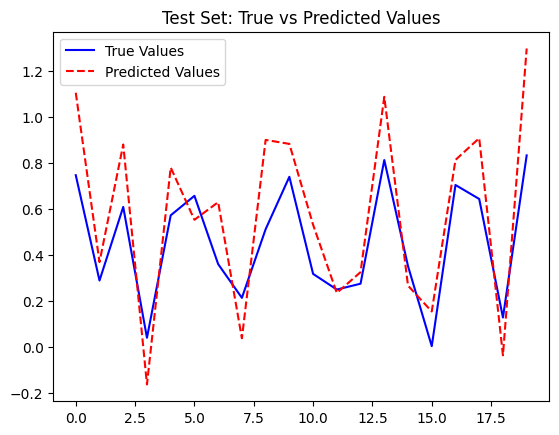

In [ ]:
# Visualize true vs. predicted values
plt.plot(y_test, label="True Values", color='blue')
plt.plot(y_pred, label="Predicted Values", color='red', linestyle='dashed')
plt.legend()
plt.title("Test Set: True vs Predicted Values")
plt.show()

We implemented this code to plot true vs. predicted values to visually assess the model's performance. By comparing both sets of values in a line plot; we can see how closely the predicted values follow the true values and whether the model is performing well or not.

- plt.plot(y_test, label="True Values", color='blue')
  - This plots the true values (y_test) against the x-axis (test data indices).
  - color set to blue, and label for the legend is set to "True Values."

- plt.plot(y_pred, label="Predicted Values", color='red', linestyle='dashed')
  - plots the predicted values (y_pred) from the model.
  - color is set to red, and the line style is set to dashed for distinction.
  - predicted values are plotted alongside the true values to visually compare the model's performance.

- plt.legend()
  - adds a legend to the plot, which labels the blue line as "True Values" and red dashed line as "Predicted Values."
  - legend makes it clear which line corresponds to which set of values.

- plt.title("Test Set: True vs Predicted Values")
  - adds a title to the plot, describing what the graph represents.
  - helps viewers understand that the graph is comparing true vs. predicted values on the test set.
- plt.show()
  - displays the plot on the screen.
  - necessary to actually render and visualize the graph.

- Output Analysis:
  - The predicted values closely follow the overall trend of the true values but exhibit noticeable deviations at certain points.
  - The model appears to struggle slightly with sharp fluctuations in the true values, leading to underestimation or overestimation in those regions.
  - The alignment of trends indicates the ESN model captures the general dynamics of the system, though there is room for improvement in handling noise or abrupt changes.